In [30]:
# ============================================================
# AI-Powered Customer Churn Intelligence System
# Day 1 - Data Understanding & Exploratory Data Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Load dataset
df = pd.read_csv("../data/customer_subscription_churn_usage_patterns.csv")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 2800
Columns: 10


## 1. Dataset Overview

The dataset contains customer subscription, usage, support, payment, and engagement information.

The primary objective is to understand customer behavior and identify patterns associated with customer churn before developing the predictive machine learning model.

In [31]:
# Preview the dataset
df.head()

,user_id,signup_date,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,1,2023-04-15,Premium,699,1.1,4,1,8,14,Yes
1,2,2023-08-27,Premium,699,2.6,6,0,35,1,Yes
2,3,2023-10-12,Premium,699,14.3,8,3,2,14,Yes
3,4,2023-12-11,Basic,199,17.6,5,2,11,9,Yes
4,5,2023-02-14,Basic,199,9.8,5,2,6,38,Yes


In [32]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 2800 non-null   int64  
 1   signup_date             2800 non-null   object 
 2   plan_type               2800 non-null   object 
 3   monthly_fee             2800 non-null   int64  
 4   avg_weekly_usage_hours  2800 non-null   float64
 5   support_tickets         2800 non-null   int64  
 6   payment_failures        2800 non-null   int64  
 7   tenure_months           2800 non-null   int64  
 8   last_login_days_ago     2800 non-null   int64  
 9   churn                   2800 non-null   object 
dtypes: float64(1), int64(6), object(3)
memory usage: 218.9+ KB


In [33]:
# Statistical summary of numerical variables
df.describe()

,user_id,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,434.214286,12.891429,3.887857,2.491786,18.612857,30.005000
std,808.434702,205.678472,7.109691,2.606419,1.691647,10.374487,17.852757
min,1.000000,199.000000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,700.750000,199.000000,6.700000,2.000000,1.000000,10.000000,14.000000
50%,1400.500000,399.000000,12.800000,4.000000,2.000000,18.000000,30.000000
75%,2100.250000,699.000000,19.200000,6.000000,4.000000,27.000000,46.000000
max,2800.000000,699.000000,25.000000,8.000000,5.000000,36.000000,60.000000


## 2. Data Quality Check

Before performing analysis, the dataset is checked for missing values, duplicate records, and data-type consistency.

In [34]:
# Missing values
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values by column:
user_id                   0
signup_date               0
plan_type                 0
monthly_fee               0
avg_weekly_usage_hours    0
support_tickets           0
payment_failures          0
tenure_months             0
last_login_days_ago       0
churn                     0
dtype: int64

Total missing values: 0


In [35]:
# Duplicate records
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [36]:
# Unique values in categorical columns
print("Plan types:")
print(df["plan_type"].value_counts())

print("\nChurn distribution:")
print(df["churn"].value_counts())

Plan types:
plan_type
Premium     944
Standard    933
Basic       923
Name: count, dtype: int64

Churn distribution:
churn
Yes    1605
No     1195
Name: count, dtype: int64


## 3. Initial Business Questions

The exploratory analysis will investigate:

- How common is customer churn?
- Which subscription plans have higher churn?
- Does customer usage differ between churned and retained customers?
- Does support-ticket activity relate to churn?
- Are payment failures associated with churn?
- Does customer tenure influence churn?
- Does recent login activity indicate churn risk?

In [37]:
# Churn percentage
churn_percentage = df["churn"].value_counts(normalize=True) * 100

print("Churn distribution (%):")
print(churn_percentage.round(2))

Churn distribution (%):
churn
Yes    57.32
No     42.68
Name: proportion, dtype: float64


In [38]:
df["churn"].value_counts()

churn
Yes    1605
No     1195
Name: count, dtype: int64

In [39]:
df["plan_type"].value_counts()

plan_type
Premium     944
Standard    933
Basic       923
Name: count, dtype: int64

## 4. Churn Analysis

This section examines the distribution of customer churn and compares churn behavior across subscription plans.

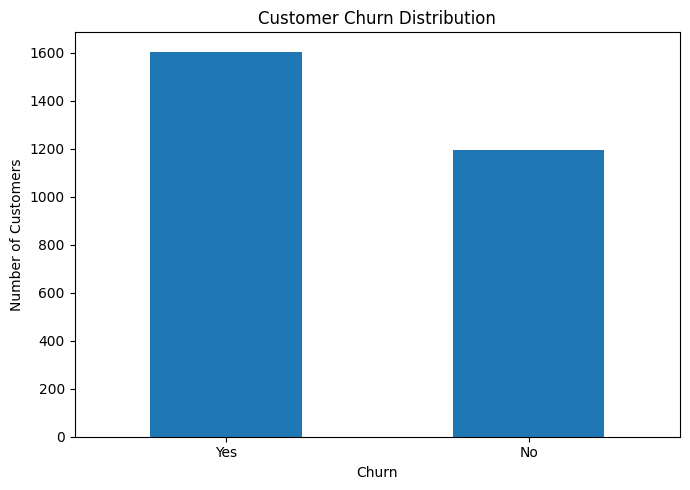

In [40]:
# Overall churn distribution

churn_counts = df["churn"].value_counts()

plt.figure(figsize=(7, 5))
churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
# Calculate churn rate by subscription plan

plan_churn = pd.crosstab(
    df["plan_type"],
    df["churn"],
    normalize="index"
) * 100

print("Churn rate by subscription plan:")
print(plan_churn.round(2))

Churn rate by subscription plan:
churn         No    Yes
plan_type              
Basic      42.15  57.85
Premium    41.95  58.05
Standard   43.94  56.06


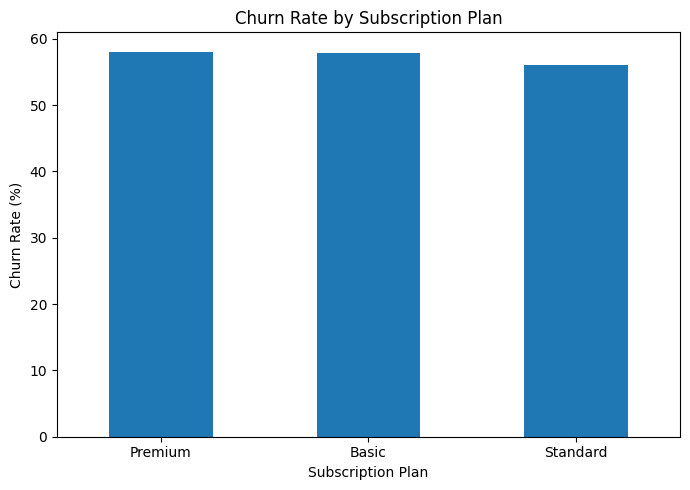

In [42]:
# Visualize churn rate by subscription plan

plan_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
# Compare average weekly usage between churned and retained customers

usage_by_churn = df.groupby("churn")["avg_weekly_usage_hours"].mean()

print("Average weekly usage by churn status:")
print(usage_by_churn.round(2))

Average weekly usage by churn status:
churn
No     13.75
Yes    12.25
Name: avg_weekly_usage_hours, dtype: float64


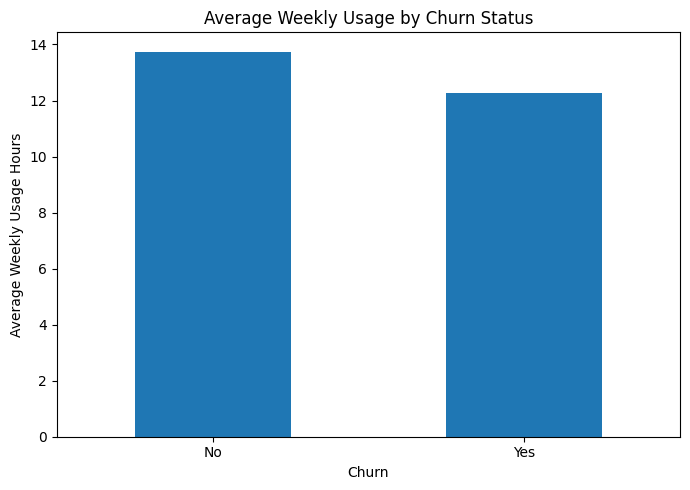

In [44]:
plt.figure(figsize=(7, 5))

usage_by_churn.plot(kind="bar")

plt.title("Average Weekly Usage by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Weekly Usage Hours")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [45]:
support_by_churn = df.groupby("churn")["support_tickets"].mean()

print("Average support tickets by churn status:")
print(support_by_churn.round(2))

Average support tickets by churn status:
churn
No     3.44
Yes    4.22
Name: support_tickets, dtype: float64


In [46]:
payment_by_churn = df.groupby("churn")["payment_failures"].mean()

print("Average payment failures by churn status:")
print(payment_by_churn.round(2))

Average payment failures by churn status:
churn
No     2.07
Yes    2.80
Name: payment_failures, dtype: float64


In [47]:
tenure_by_churn = df.groupby("churn")["tenure_months"].mean()

print("Average tenure by churn status:")
print(tenure_by_churn.round(2))

Average tenure by churn status:
churn
No     18.59
Yes    18.63
Name: tenure_months, dtype: float64


In [48]:
login_by_churn = df.groupby("churn")["last_login_days_ago"].mean()

print("Average days since last login by churn status:")
print(login_by_churn.round(2))

Average days since last login by churn status:
churn
No     26.15
Yes    32.88
Name: last_login_days_ago, dtype: float64


## 5. Numerical Feature Analysis

This section compares the distributions of key numerical customer attributes across churn status to identify behavioral patterns that may contribute to customer churn.

In [49]:
# Numerical features
numerical_features = [
    "monthly_fee",
    "avg_weekly_usage_hours",
    "support_tickets",
    "payment_failures",
    "tenure_months",
    "last_login_days_ago"
]

# Compare averages by churn status
numeric_comparison = df.groupby("churn")[numerical_features].mean().T

print("Average numerical features by churn status:")
print(numeric_comparison.round(2))

Average numerical features by churn status:
churn                       No     Yes
monthly_fee             433.31  434.89
avg_weekly_usage_hours   13.75   12.25
support_tickets           3.44    4.22
payment_failures          2.07    2.80
tenure_months            18.59   18.63
last_login_days_ago      26.15   32.88


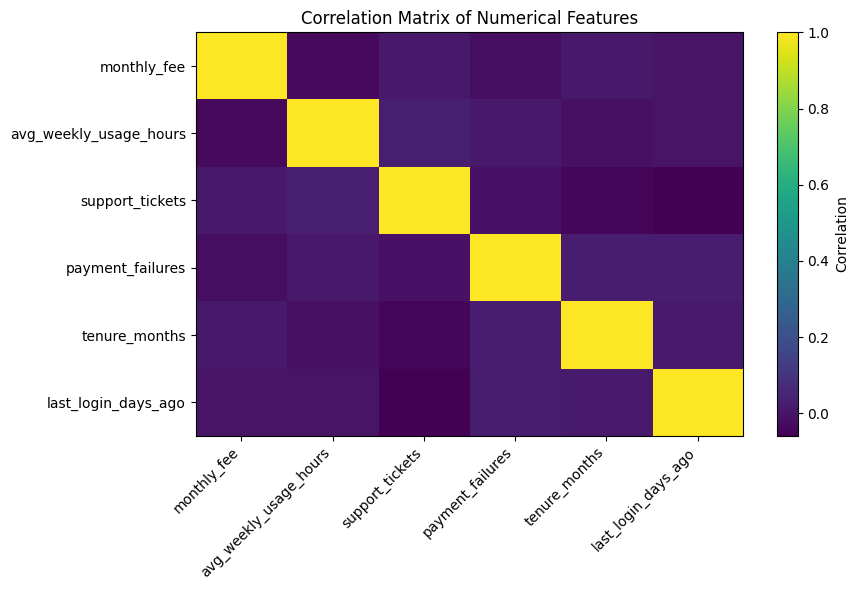

In [50]:
# Correlation matrix for numerical variables

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(9, 6))
plt.imshow(correlation_matrix, aspect="auto")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar(label="Correlation")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

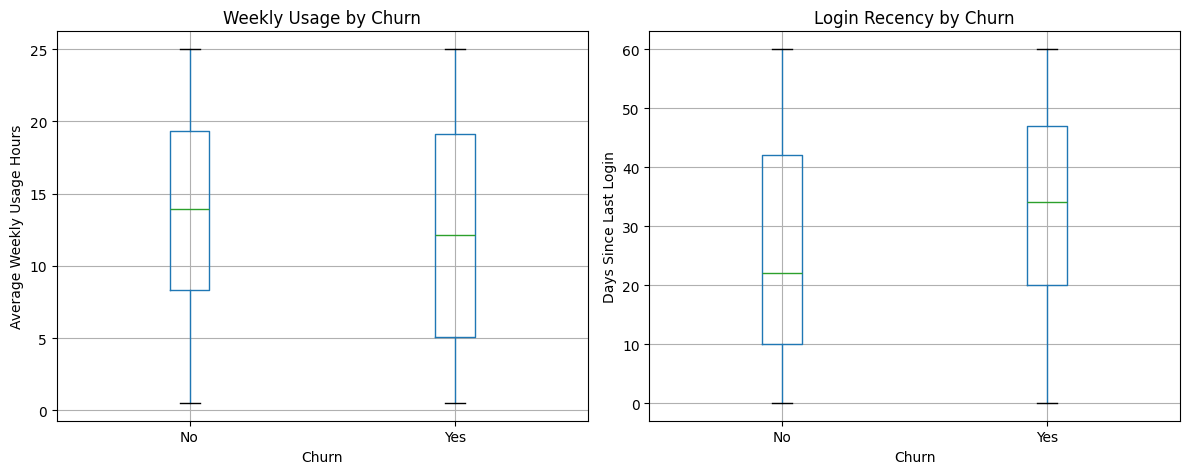

In [51]:
# Usage and login recency comparison

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(
    column="avg_weekly_usage_hours",
    by="churn",
    ax=axes[0]
)

axes[0].set_title("Weekly Usage by Churn")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Average Weekly Usage Hours")

df.boxplot(
    column="last_login_days_ago",
    by="churn",
    ax=axes[1]
)

axes[1].set_title("Login Recency by Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Days Since Last Login")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [52]:
# Preliminary business comparison

insights = pd.DataFrame({
    "Metric": [
        "Support Tickets",
        "Payment Failures",
        "Tenure (Months)",
        "Days Since Last Login",
        "Weekly Usage Hours"
    ],
    "Churned Customers": [
        df[df["churn"] == "Yes"]["support_tickets"].mean(),
        df[df["churn"] == "Yes"]["payment_failures"].mean(),
        df[df["churn"] == "Yes"]["tenure_months"].mean(),
        df[df["churn"] == "Yes"]["last_login_days_ago"].mean(),
        df[df["churn"] == "Yes"]["avg_weekly_usage_hours"].mean()
    ],
    "Retained Customers": [
        df[df["churn"] == "No"]["support_tickets"].mean(),
        df[df["churn"] == "No"]["payment_failures"].mean(),
        df[df["churn"] == "No"]["tenure_months"].mean(),
        df[df["churn"] == "No"]["last_login_days_ago"].mean(),
        df[df["churn"] == "No"]["avg_weekly_usage_hours"].mean()
    ]
})

insights["Difference"] = (
    insights["Churned Customers"] -
    insights["Retained Customers"]
)

insights.round(2)

,Metric,Churned Customers,Retained Customers,Difference
0,Support Tickets,4.22,3.44,0.79
1,Payment Failures,2.80,2.07,0.73
2,Tenure (Months),18.63,18.59,0.04
3,Days Since Last Login,32.88,26.15,6.73
4,Weekly Usage Hours,12.25,13.75,-1.49


## 6. Categorical Feature Analysis

This section examines customer churn across subscription plans to identify whether churn behavior differs meaningfully between customer segments.

In [53]:
# Churn rate by subscription plan

plan_churn_rate = (
    pd.crosstab(
        df["plan_type"],
        df["churn"],
        normalize="index"
    )["Yes"] * 100
).sort_values(ascending=False)

print("Churn rate by subscription plan:")
print(plan_churn_rate.round(2))

Churn rate by subscription plan:
plan_type
Premium     58.05
Basic       57.85
Standard    56.06
Name: Yes, dtype: float64


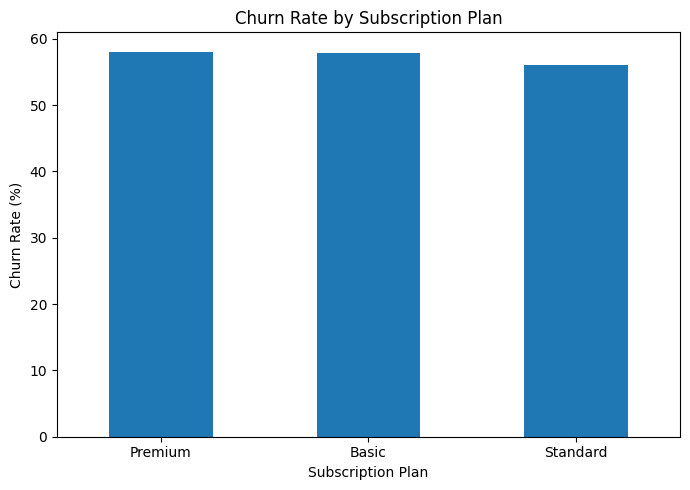

In [54]:
plt.figure(figsize=(7, 5))

plan_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [55]:
# Convert signup date to datetime

df["signup_date"] = pd.to_datetime(df["signup_date"])

df["signup_year"] = df["signup_date"].dt.year

print("Customers by signup year:")
print(df["signup_year"].value_counts().sort_index())

Customers by signup year:
signup_year
2023    1347
2024    1453
Name: count, dtype: int64


In [56]:
# Churn rate by signup year

signup_year_churn = (
    pd.crosstab(
        df["signup_year"],
        df["churn"],
        normalize="index"
    )["Yes"] * 100
)

print("Churn rate by signup year:")
print(signup_year_churn.round(2))

Churn rate by signup year:
signup_year
2023    55.98
2024    58.57
Name: Yes, dtype: float64


## 7. Key Business Insights

The exploratory analysis identified several initial patterns associated with customer churn:

- Overall customer churn is relatively high, with 1,605 of 2,800 customers classified as churned.
- Churned customers have a higher average number of support tickets (4.22) compared with retained customers (3.44).
- Churned customers experience more payment failures on average (2.80) than retained customers (2.07).
- Churned customers have a higher average number of days since their last login (32.88 days) compared with retained customers (26.15 days), indicating lower recent engagement.
- Average weekly usage is slightly lower among churned customers (12.25 hours) than retained customers (13.75 hours).
- Average tenure is almost identical between churned and retained customers, suggesting that tenure alone does not show a meaningful difference in this dataset.
- Churn rates across subscription plans are relatively similar, with Premium at 58.05%, Basic at 57.85%, and Standard at 56.06%.
- Customers who signed up in 2024 have a slightly higher churn rate (58.57%) than customers who signed up in 2023 (55.98%).

These findings provide initial hypotheses for the predictive modeling stage. The machine learning model and SHAP analysis will be used later to determine which features contribute most strongly to individual churn predictions.

In [57]:
# Final EDA summary

print("========== EDA SUMMARY ==========")
print(f"Total customers: {len(df):,}")
print(f"Churned customers: {(df['churn'] == 'Yes').sum():,}")
print(f"Retained customers: {(df['churn'] == 'No').sum():,}")
print(f"Overall churn rate: {(df['churn'] == 'Yes').mean() * 100:.2f}%")
print(f"Average weekly usage: {df['avg_weekly_usage_hours'].mean():.2f} hours")
print(f"Average support tickets: {df['support_tickets'].mean():.2f}")
print(f"Average payment failures: {df['payment_failures'].mean():.2f}")

========== EDA SUMMARY ==========
Total customers: 2,800
Churned customers: 1,605
Retained customers: 1,195
Overall churn rate: 57.32%
Average weekly usage: 12.89 hours
Average support tickets: 3.89
Average payment failures: 2.49
